    model_name   Round model_type uniprot_type      RMSD
0       Delete  Round1   hit2lead          all  0.197261
1       Delete  Round1   hit2lead         seen  0.211976
2       Delete  Round1   hit2lead       unseen  0.161940
3      DiffDec  Round1   hit2lead          all  0.217907
4      DiffDec  Round1   hit2lead         seen  0.227507
5      DiffDec  Round1   hit2lead       unseen  0.194268
6   DiffSBDD-C  Round1   hit2lead          all  0.153850
7   DiffSBDD-C  Round1   hit2lead         seen  0.160176
8   DiffSBDD-C  Round1   hit2lead       unseen  0.137809
9   DiffSBDD-M  Round1   hit2lead          all  0.182661
10  DiffSBDD-M  Round1   hit2lead         seen  0.189558
11  DiffSBDD-M  Round1   hit2lead       unseen  0.164928
12    ShEPhERD  Round1   hit2lead          all  0.123357
13    ShEPhERD  Round1   hit2lead         seen  0.130078
14    ShEPhERD  Round1   hit2lead       unseen  0.106635
15      Delete  Round2   hit2lead          all  0.197683
16      Delete  Round2   hit2le

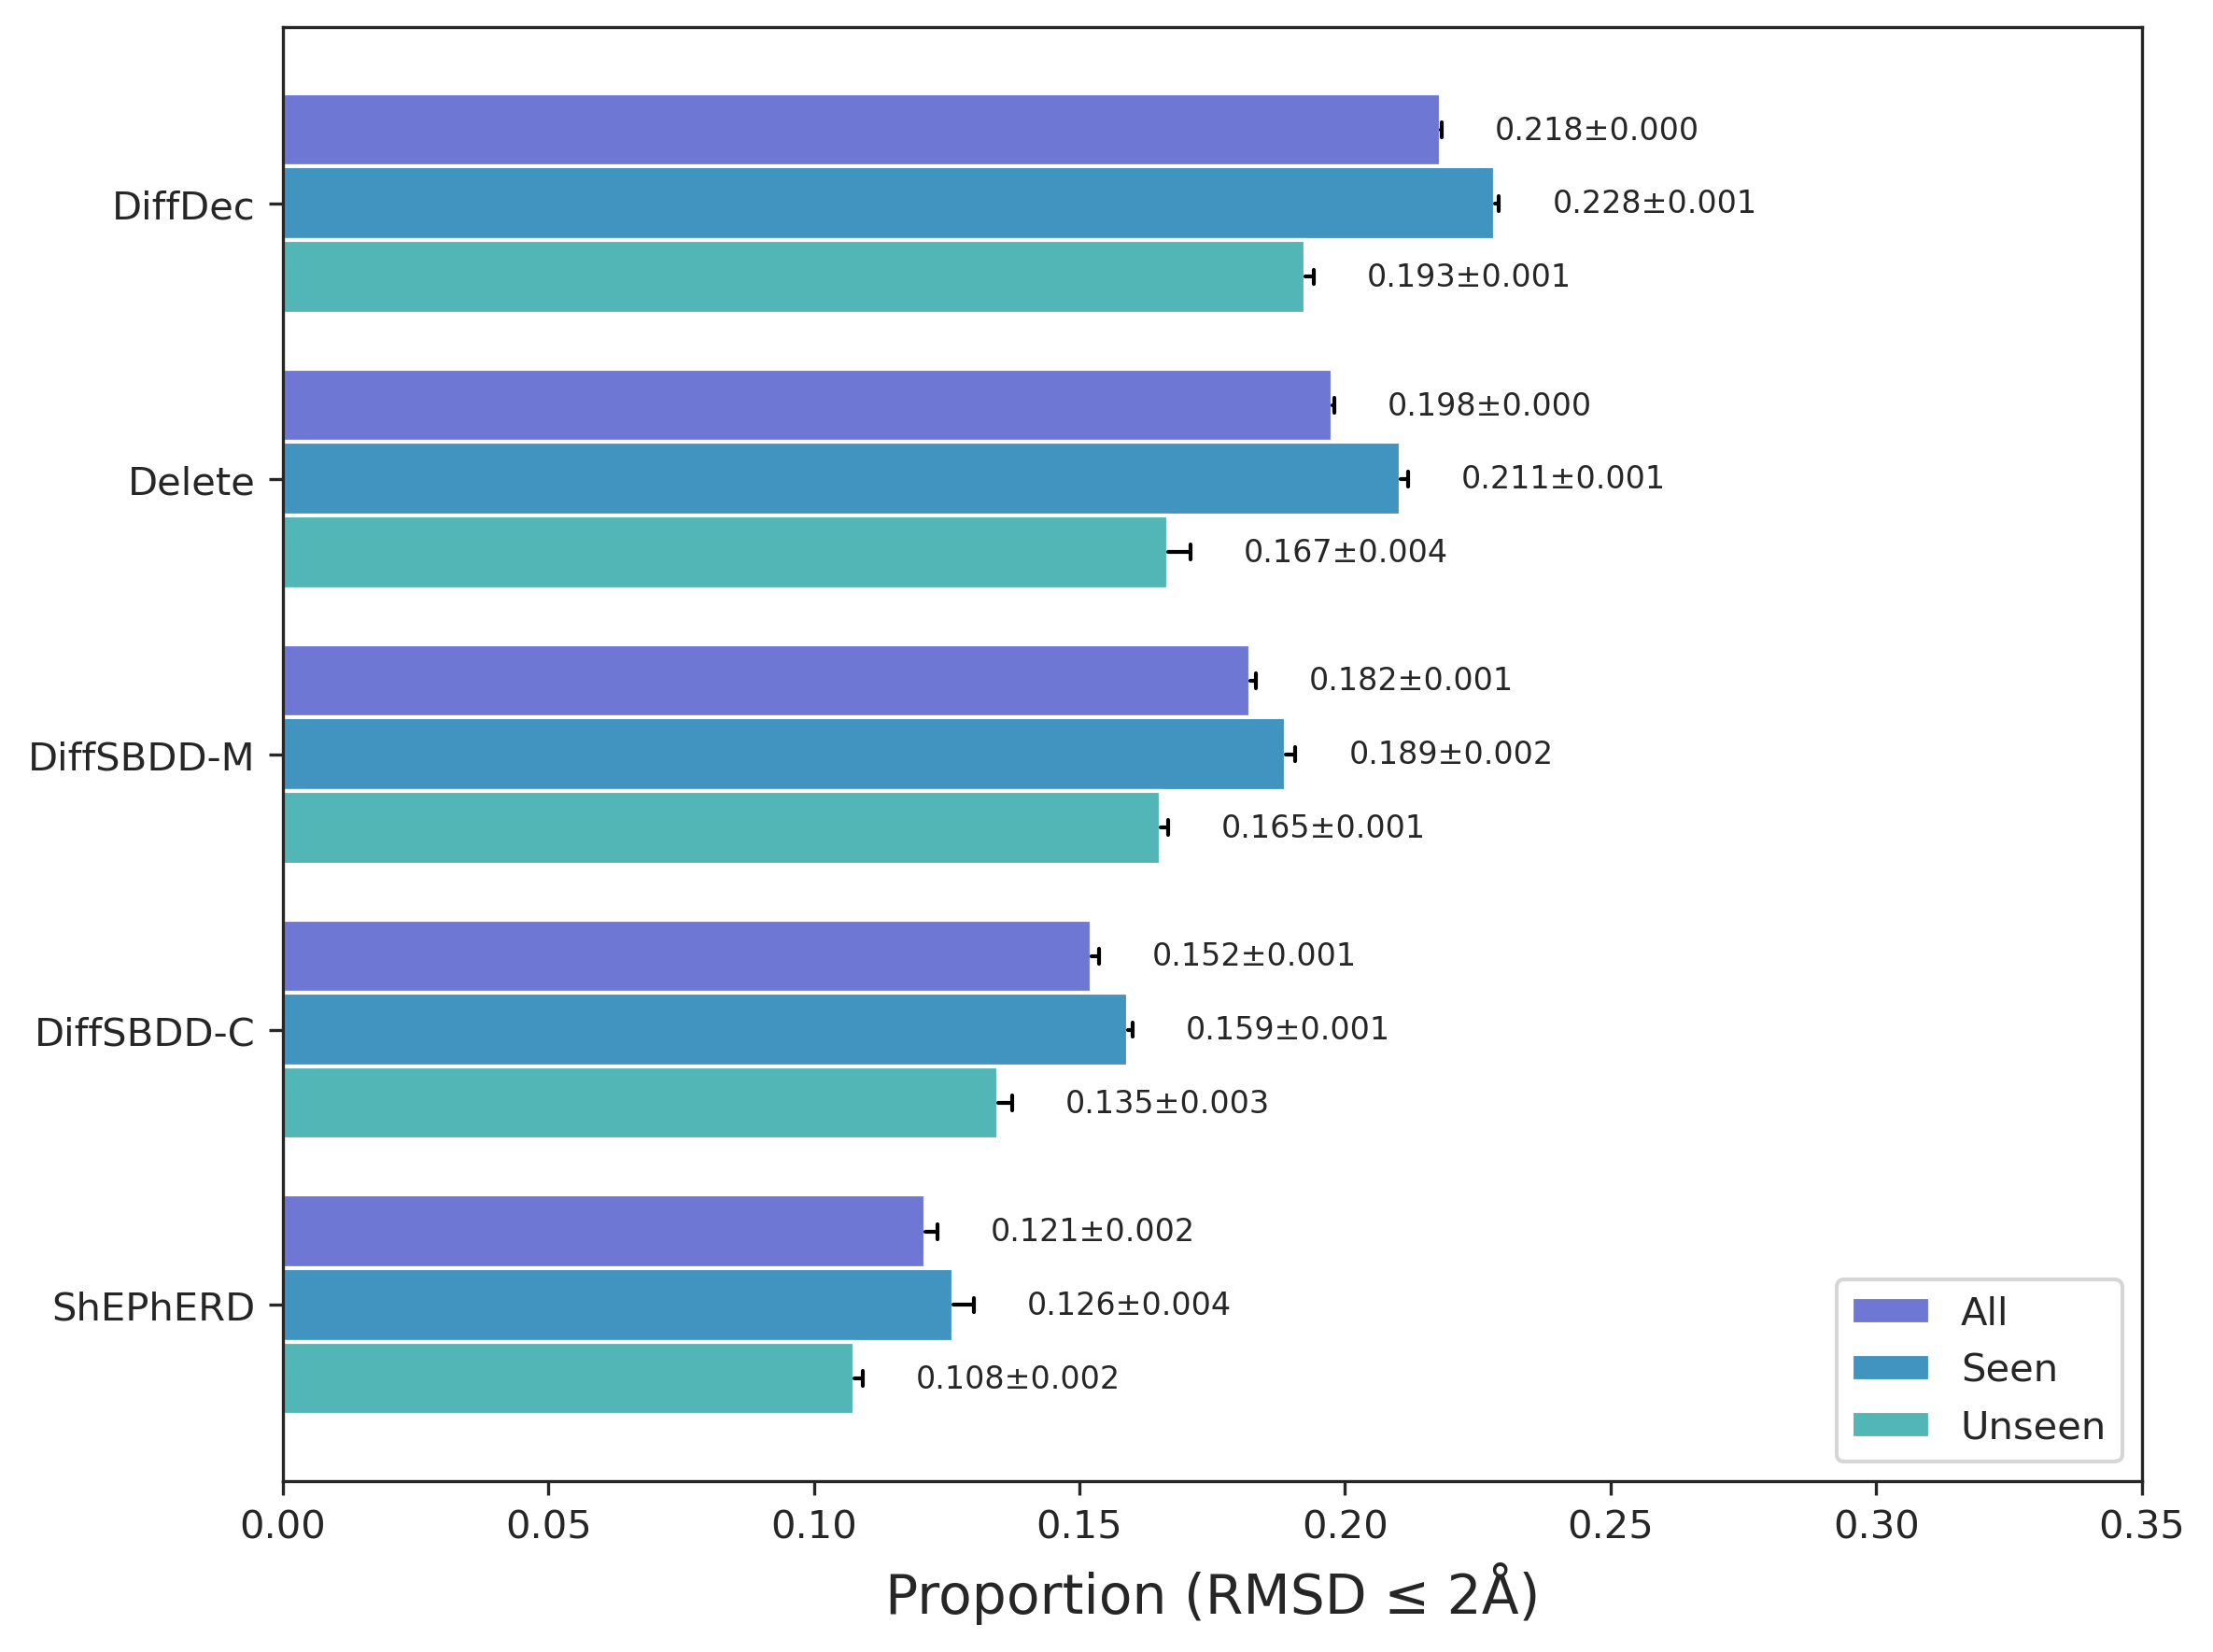

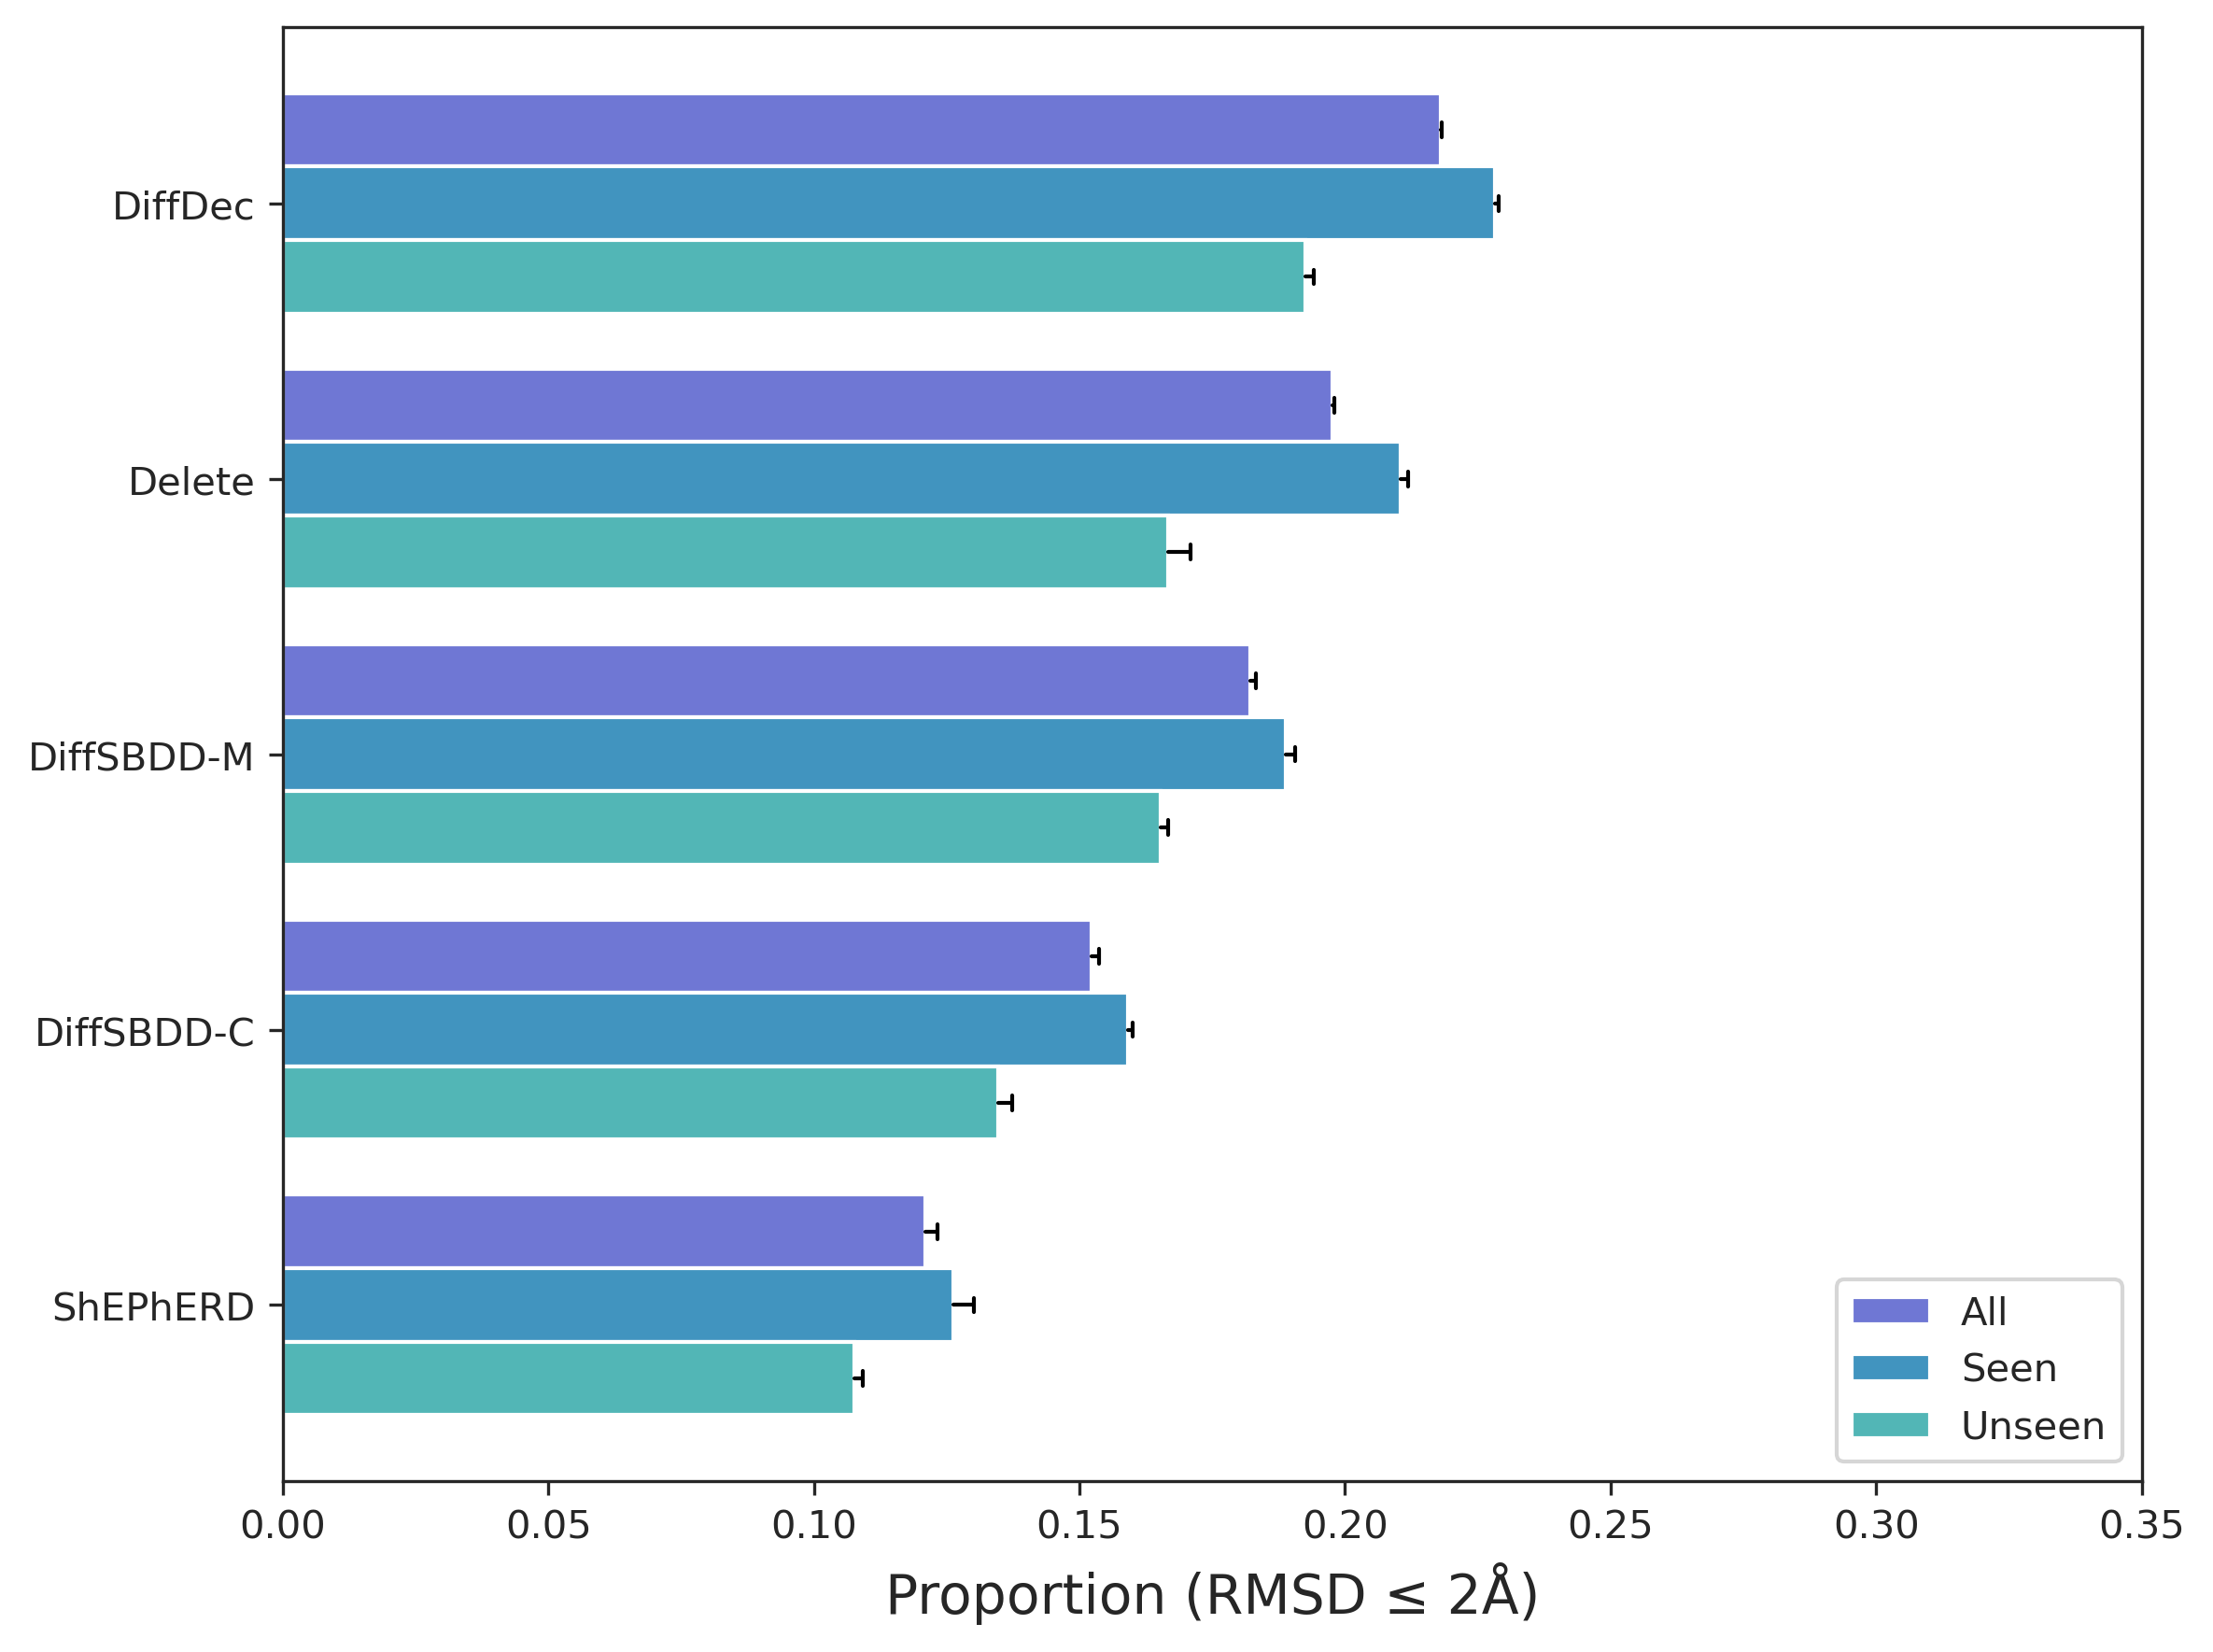

In [ ]:
import os
import pandas as pd
import numpy as np
import yaml
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch


# ========== 数据读取 ==========
data_path = "/home/user-home/fanzhehuan/myprojects/MolGenBench/paper_results"
save_fig_dir = "../final_plot/output/"

round_list = ["Round1", "Round2", "Round3"]
mode_list = ["Hit_to_Lead_Results"]

TASK_LIST_H2L = [
    "DeleteHit2Lead(CrossDock)_Hit_to_Lead",
    "DiffDec_Hit_to_Lead",
    "diffSBDD_cond_crossdocked_Hit_to_Lead",
    "diffSBDD_cond_moad_Hit_to_Lead",
    # "PGMG_Hit_to_Lead",
    # "ShapeMol_Hit_to_Lead",
    "shepherd_x1x3x4_mosesaq_submission_Hit_to_Lead",
]

H2L_NAME_MAPPING = {
    "DiffDec_Hit_to_Lead": "DiffDec",
    "diffSBDD_cond_crossdocked_Hit_to_Lead": "DiffSBDD-C",
    "diffSBDD_cond_moad_Hit_to_Lead": "DiffSBDD-M",
    # "ShapeMol_Hit_to_Lead": "ShapeMol",
    "shepherd_x1x3x4_mosesaq_submission_Hit_to_Lead": "ShEPhERD",
    "DeleteHit2Lead(CrossDock)_Hit_to_Lead": "Delete",
    # "PGMG_Hit_to_Lead": "PGMG",
}

results_list = []
for round_name in round_list:
    for mode in mode_list:
        task_list = TASK_LIST_H2L
        name_mapping = H2L_NAME_MAPPING
        task_type = "hit2lead"
            
        for task in task_list:
            yaml_path = os.path.join(data_path, round_name, mode, task, "results.yaml")
            if not os.path.exists(yaml_path):
                print(f"Warning: {yaml_path} not found")
                continue
                
            with open(yaml_path, 'r') as f:
                result = yaml.safe_load(f)

                # 分别存储 all/seen/unseen
                for uniprot_type in ['all', 'seen', 'unseen']:
                    try:
                        rmsd_value = result['metrics']['RMSD'][uniprot_type]['RMSD_<2']
                    except (KeyError, TypeError):
                        print(f"Warning: RMSD not found for {task} - {uniprot_type}")
                        rmsd_value = 0.0
                        
                    results_list.append({
                        "model_name": name_mapping[task],
                        "Round": round_name,
                        "model_type": task_type,
                        "uniprot_type": uniprot_type,
                        "RMSD": rmsd_value,
                    })
                    

df_results_h2l = pd.DataFrame(results_list)
print(df_results_h2l)


# ========== 绘图函数（适配新数据格式） ==========
def rmsd_bar_plot_grouped_from_yaml(df_results, annot=True, save_path=None, xlim_max=0.35):
    """
    从 YAML 读取的数据绑图
    
    Parameters:
    -----------
    df_results : DataFrame
        包含 model_name, Round, model_type, uniprot_type, RMSD 列
    annot : bool
        是否显示数值标注
    save_path : str
        保存路径
    xlim_max : float
        x 轴最大值
    """
    
    def summarize(df, uniprot_type, label):
        """聚合某个 uniprot_type 的数据，计算 mean 和 std"""
        df_filtered = df[df['uniprot_type'] == uniprot_type]
        
        # 按 model_name 聚合，计算 3 个 Round 的 mean 和 std
        df_summary = (
            df_filtered
            .groupby('model_name')['RMSD']
            .agg(['mean', 'std'])
            .reset_index()
        )
        df_summary.columns = ['Model', 'Mean', 'Std']
        df_summary['Dataset'] = label
        df_summary['Std'] = df_summary['Std'].fillna(0)
        return df_summary

    # 分别聚合 all/seen/unseen
    df_all_summary = summarize(df_results, 'all', 'All')
    df_seen_summary = summarize(df_results, 'seen', 'Seen')
    df_unseen_summary = summarize(df_results, 'unseen', 'Unseen')

    df_summary = pd.concat([df_all_summary, df_seen_summary, df_unseen_summary])

    # 按 All 的 Mean 排序
    order = df_all_summary.sort_values('Mean', ascending=False)['Model']
    
    # 按排序顺序重新组织数据（用于误差条绑制）
    df_summary_sorted = pd.concat([
        df_summary[df_summary['Dataset'] == ds].set_index('Model').loc[order].reset_index()
        for ds in ['All', 'Seen', 'Unseen']
    ])
    
    palette = {
        "All": "#5E69E5",   
        "Seen": "#2C9AD4", 
        "Unseen": "#41C7C7" 
    }

    plt.figure(figsize=(8, 6), dpi=300)
    sns.set_style('ticks')

    ax = sns.barplot(
        data=df_summary,
        x='Mean',
        y='Model',
        hue='Dataset',
        order=order,
        palette=palette,
        capsize=0.1,
    )
    
    # 添加误差条和标注
    for bar, (_, row) in zip(ax.patches, df_summary_sorted.iterrows()):
        x = bar.get_width()
        y = bar.get_y() + bar.get_height() / 2
        mean, std = row['Mean'], row['Std']

        # 绘制误差条（横线）
        ax.plot([x, x + std], [y, y], color='black', linewidth=1)
        # 绘制误差条末端（竖线）
        ax.plot([x + std, x + std], [y - 0.1 * bar.get_height(), y + 0.1 * bar.get_height()],
                color='black', linewidth=1)
        
        # 添加数值标注
        if annot:
            ax.text(x + std + 0.01, y,
                    f"{mean:.3f}±{std:.3f}",
                    va='center', ha='left', fontsize=8)

    plt.xlabel('Proportion (RMSD ≤ 2Å)', fontsize=14)
    plt.ylabel('')
    plt.xlim(0, xlim_max)
    plt.legend(loc='lower right')
    plt.tight_layout()

    if save_path:
        plt.savefig(
            save_path,
            format='svg',
            bbox_inches='tight',
        )
    plt.show()
    plt.close()


# ========== 调用绑图 ==========
os.makedirs(save_fig_dir, exist_ok=True)

# 带标注
rmsd_bar_plot_grouped_from_yaml(
    df_results_h2l, 
    annot=True, 
    save_path=os.path.join(save_fig_dir, "05-rmsd_bar_hit2lead_RotatableBond15_vina_grouped.svg"),
    xlim_max=0.35
)

# 不带标注
rmsd_bar_plot_grouped_from_yaml(
    df_results_h2l, 
    annot=False, 
    save_path=os.path.join(save_fig_dir, "05-rmsd_bar_hit2lead_RotatableBond15_vina_grouped_NoNmber.svg"),
    xlim_max=0.35
)